In [ ]:
print("--- DATA ---")

d: list[str] = open('./data/names.txt', 'r').read().splitlines()
D: int = len(d)

for di in d[:3]: # loop through the dataset ..
  print(f'a single word di {di} has many examples')
  for h,w in zip(di, di[1:]): # .. in a self-supervised manner
    print(f'our machine learner is being supervised output {w} for input {h}!')

--- JOINT ---
vocab: ['Hello', 'world', 'nice', 'to', 'meet']
p(w_(t-1), w_t) as (5, 5) ndarray:
[[0.01 0.15 0.01 0.02 0.01]
 [0.01 0.01 0.16 0.01 0.01]
 [0.01 0.01 0.01 0.16 0.01]
 [0.01 0.01 0.01 0.01 0.16]
 [0.14 0.02 0.01 0.02 0.01]]


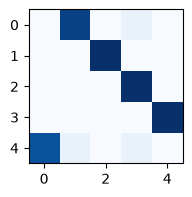

p(w_(t-1)=to, w_t=meet) = 0.16


In [27]:
print("--- JOINT ---")
import numpy as np
import matplotlib.pyplot as plt

v: list[str] = ['Hello', 'world', 'nice', 'to', 'meet']
V: int = len(v)
toi, meeti = 3, 4

# Figure I.2 as an ndarray every cell is the joint probability of a (previous word, next word) pair.
p_VV = np.array([                     #  w_t: Hello world  nice    to  meet
  [0.01, 0.15, 0.01, 0.02, 0.01],       #  w_{t-1} = Hello  (i=0)
  [0.01, 0.01, 0.16, 0.01, 0.01],       #  w_{t-1} = world  (i=1)
  [0.01, 0.01, 0.01, 0.16, 0.01],       #  w_{t-1} = nice   (i=2)
  [0.01, 0.01, 0.01, 0.01, 0.16],       #  w_{t-1} = to     (i=3)
  [0.14, 0.02, 0.01, 0.02, 0.01],       #  w_{t-1} = meet   (i=4)
])
assert p_VV.shape == (V, V)
assert np.isclose(p_VV.sum(), 1.0)    # normalization, over the *whole* table
print(f'vocab: {v}')
print(f'p(w_(t-1), w_t) as {p_VV.shape} ndarray:\n{p_VV}')
plt.figure(figsize=(2, 2))
plt.imshow(p_VV, cmap='Blues')
plt.show()
print(f'p(w_(t-1)=to, w_t=meet) = {p_VV[toi, meeti]:.2f}')

--- JOINT ---
vocab: ['Hello', 'world', 'nice', 'to', 'meet']
p(w_(t-1), w_t) as (5, 5) ndarray:
[[0.01 0.15 0.01 0.02 0.01]
 [0.01 0.01 0.16 0.01 0.01]
 [0.01 0.01 0.01 0.16 0.01]
 [0.01 0.01 0.01 0.01 0.16]
 [0.14 0.02 0.01 0.02 0.01]]


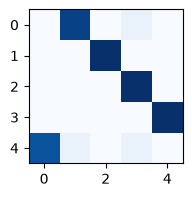

p(w_(t-1)=to, w_t=meet) = 0.16
(3,)


TypeCheckError: Type-check error whilst checking the parameters of __main__.printp_VV.
The problem arose whilst typechecking parameter 'p_VV'.
Actual value: f64[3](numpy)
Expected type: <class 'Float[ndarray, 'V V']'>.
----------------------
Called with parameters: {'p_VV': f64[3](numpy)}
Parameter annotations: (p_VV: Float[ndarray, 'V V']) -> Any.


In [ ]:
print("--- JOINT ---")
import numpy as np
import matplotlib.pyplot as plt
from jaxtyping import Float, jaxtyped
from beartype import beartype

v: list[str] = ['Hello', 'world', 'nice', 'to', 'meet']
V: int = len(v)
toi, meeti = 3, 4

# Figure I.2 as an ndarray
p_VV = np.array([
  [0.01, 0.15, 0.01, 0.02, 0.01],
  [0.01, 0.01, 0.16, 0.01, 0.01],
  [0.01, 0.01, 0.01, 0.16, 0.01],
  [0.01, 0.01, 0.01, 0.01, 0.16],
  [0.14, 0.02, 0.01, 0.02, 0.01],
])

@jaxtyped(typechecker=beartype)
def printp_VV(p_VV: Float[np.ndarray, "V V"]):
  assert np.isclose(p_VV.sum(), 1.0)    # normalization, over the *whole* table
  print(f'vocab: {v}')
  print(f'p(w_(t-1), w_t) as {p_VV.shape} ndarray:\n{p_VV}')
  plt.figure(figsize=(2, 2))
  plt.imshow(p_VV, cmap='Blues')
  plt.show()                            # flush *now*, else inline defers it to end of cell
  print(f'p(w_(t-1)=to, w_t=meet) = {p_VV[toi, meeti]:.2f}')

printp_VV(p_VV)
p_VV = np.zeros(3)
printp_VV(p_VV)

In [24]:
print(f'p(w_(t-1)=to, w_t=meet) = {p_VV[3, :]}')
print(f'p(w_(t-1)=to, w_t=meet) = {p_VV[:, 4]}')

p(w_(t-1)=to, w_t=meet) = [0.01 0.01 0.01 0.01 0.16]
p(w_(t-1)=to, w_t=meet) = [0.01 0.01 0.01 0.16 0.01]


In [2]:
print("--- MARGINAL ---")
pW1_V = p_VV.sum(axis=1) # sum over W_2
pW2_V = p_VV.sum(axis=0) # sum over W_1
assert np.isclose(pW1_V.sum(), 1.0) and np.isclose(pW2_V.sum(), 1.0)
print(f'p(w_(t-1)) as {pW1_V.shape} ndarray (row sums): {pW1_V}')
print(f'p(w_t)     as {pW2_V.shape} ndarray (col sums): {pW2_V}')

--- MARGINAL ---
p(w_(t-1)) as (5,) ndarray (row sums): [0.2 0.2 0.2 0.2 0.2]
p(w_t)     as (5,) ndarray (col sums): [0.18 0.2  0.2  0.22 0.2 ]


In [ ]:
# CONDITIONING is the joint over the marginal being conditioned on. keepdims
# holds the row sums at (V,1) so they broadcast back across the (V,V) joint,
# dividing each row by its own total -- ie. *renormalizing* the row.
pW2condW1_VV = p_VV / p_VV.sum(axis=1, keepdims=True)
assert np.allclose(pW2condW1_VV.sum(axis=1), 1.0)  # now every *row* sums to 1

print(f'\np(w_t|w_(t-1)) as {pW2condW1_VV.shape} ndarray:\n{pW2condW1_VV}')
print(f'every row sums to {pW2condW1_VV.sum(axis=1)}')
i_to, j_meet = toi, meeti
print(f'\np(meet|to) = p(to,meet)/p(to) = {p_VV[i_to,j_meet]:.2f}/{pW1_V[i_to]:.2f} = {pW2condW1_VV[i_to,j_meet]:.2f}')


p(w_t|w_(t-1)) as (5, 5) ndarray:
[[0.05 0.75 0.05 0.1  0.05]
 [0.05 0.05 0.8  0.05 0.05]
 [0.05 0.05 0.05 0.8  0.05]
 [0.05 0.05 0.05 0.05 0.8 ]
 [0.7  0.1  0.05 0.1  0.05]]
every row sums to [1. 1. 1. 1. 1.]

p(meet|to) = p(to,meet)/p(to) = 0.16/0.20 = 0.80


In [4]:
print("--- DATA ---")

d: list[str] = open('./data/names.txt', 'r').read().splitlines()
D: int = len(d)

for di in d[:3]: # loop through the dataset ..
  print(f'a single word di {di} has many examples')
  for h,w in zip(di, di[1:]): # .. in a self-supervised manner
    print(f'our machine learner is being supervised output {w} for input {h}!')

--- DATA ---
a single word di emma has many examples
our machine learner is being supervised output m for input e!
our machine learner is being supervised output m for input m!
our machine learner is being supervised output a for input m!
a single word di olivia has many examples
our machine learner is being supervised output l for input o!
our machine learner is being supervised output i for input l!
our machine learner is being supervised output v for input i!
our machine learner is being supervised output i for input v!
our machine learner is being supervised output a for input i!
a single word di ava has many examples
our machine learner is being supervised output v for input a!
our machine learner is being supervised output a for input v!


In [5]:
d: list[str] = open('./data/names.txt', 'r').read().splitlines()
D: int = len(d)

print("--- TRAINING (counting p(w|h) with python dict ---")
# Histogram (counting frequencies) is the most precise model for training set. it *is* the training set. but it generalizes poorly.
counts_dict = {}
for di in d:
  di_normalized = ['<S>'] + list(di) + ['<E>']
  for h,w in zip(di_normalized, di_normalized[1:]): # in the case of bigrams h is a single character, so we can simply zip two strings to get a pair of characters
    # print(h, w)
    counts_dict[(h,w)] = counts_dict.get((h,w), 0) + 1
sorted_counts_dict = sorted(counts_dict.items(), key = lambda x: -x[1])
print("2D (w,h) histogram using python's dict:\n", sorted_counts_dict)

--- TRAINING (counting p(w|h) with python dict ---
2D (w,h) histogram using python's dict:
 [(('n', '<E>'), 6763), (('a', '<E>'), 6640), (('a', 'n'), 5438), (('<S>', 'a'), 4410), (('e', '<E>'), 3983), (('a', 'r'), 3264), (('e', 'l'), 3248), (('r', 'i'), 3033), (('n', 'a'), 2977), (('<S>', 'k'), 2963), (('l', 'e'), 2921), (('e', 'n'), 2675), (('l', 'a'), 2623), (('m', 'a'), 2590), (('<S>', 'm'), 2538), (('a', 'l'), 2528), (('i', '<E>'), 2489), (('l', 'i'), 2480), (('i', 'a'), 2445), (('<S>', 'j'), 2422), (('o', 'n'), 2411), (('h', '<E>'), 2409), (('r', 'a'), 2356), (('a', 'h'), 2332), (('h', 'a'), 2244), (('y', 'a'), 2143), (('i', 'n'), 2126), (('<S>', 's'), 2055), (('a', 'y'), 2050), (('y', '<E>'), 2007), (('e', 'r'), 1958), (('n', 'n'), 1906), (('y', 'n'), 1826), (('k', 'a'), 1731), (('n', 'i'), 1725), (('r', 'e'), 1697), (('<S>', 'd'), 1690), (('i', 'e'), 1653), (('a', 'i'), 1650), (('<S>', 'r'), 1639), (('a', 'm'), 1634), (('l', 'y'), 1588), (('<S>', 'l'), 1572), (('<S>', 'c'), 1542

# We will now construct the same 2d histogram, but with numpy's ndarray instead of python's dict
# Because numpy's ndarray uses numerical indices to index into, we need to create a dict[str,int]
# so that when we loop over (w,h) pairs within a word we can update the count at the correct location

In [6]:
print("--- DATA ---")
import numpy as np

d: list[str] = open('./data/names.txt', 'r').read().splitlines()
D: int = len(d)
v: list[str] = ['.'] + sorted(list(set(''.join(d)))) # with . as the start token and end token, to remove counting freq of (<E>*) and (*<S>) which are all 0
V: int = len(v)
c2i: dict[str, int] = {c:i for i,c in enumerate(v)}

print(f'dataset: {d}')
print(f'vocab (sample space): {v}')
print(f'I: V -> N: {c2i}')

--- DATA ---
dataset: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn', 'abigail', 'emily', 'elizabeth', 'mila', 'ella', 'avery', 'sofia', 'camila', 'aria', 'scarlett', 'victoria', 'madison', 'luna', 'grace', 'chloe', 'penelope', 'layla', 'riley', 'zoey', 'nora', 'lily', 'eleanor', 'hannah', 'lillian', 'addison', 'aubrey', 'ellie', 'stella', 'natalie', 'zoe', 'leah', 'hazel', 'violet', 'aurora', 'savannah', 'audrey', 'brooklyn', 'bella', 'claire', 'skylar', 'lucy', 'paisley', 'everly', 'anna', 'caroline', 'nova', 'genesis', 'emilia', 'kennedy', 'samantha', 'maya', 'willow', 'kinsley', 'naomi', 'aaliyah', 'elena', 'sarah', 'ariana', 'allison', 'gabriella', 'alice', 'madelyn', 'cora', 'ruby', 'eva', 'serenity', 'autumn', 'adeline', 'hailey', 'gianna', 'valentina', 'isla', 'eliana', 'quinn', 'nevaeh', 'ivy', 'sadie', 'piper', 'lydia', 'alexa', 'josephine', 'emery', 'julia', 'delilah', 'arianna', 'vivian', 'kaylee', 'sophie', 'brielle', 'made

In [7]:
print("--- ARCH ---")
C_VV = np.zeros((V,V), dtype=np.int32)      # and use V to construct C_VV

--- ARCH ---


In [8]:
print("--- TRAINING ---")
for di in d: # loop through the dataset ..
  di_normalized = ['.'] + list(di) + ['.']

  # .. in a self-supervised manner
  for h,w in zip(di_normalized, di_normalized[1:]):
    print(h,w)
    h_index, w_index = c2i[h], c2i[w]                                         # use map<char, ord> to lookup the coordinate index needed for C_VV
    C_VV[h_index, w_index] += 1                                                         # update C_VV
print("2D (xt,xt-1) histogram using numpy dict:\n", C_VV)

# normalize counts C_VV to probs P_VV
C_VVf32 = (C_VV+1).astype(np.float32)           # inductive bias (locally smooth)
s_V1 = C_VVf32.sum(axis=1,keepdims=True)              # reduce along axis=1 because we want p(y|x) not p(x|y)
P_VV = C_VVf32 / s_V1                                                                   # (V, V) / (V, 1) broadcasts

# for P_VV, the elements are the counts of bigrams (h,w) accessed by indexing with ord(h) at axis=0 and ord(w) at axis=1
# now, since numpy's ndarray's are row major order, axis=0 gets printed vertically from up to down while axis=1 gets printed horizontally from left to right
i2c = {i:c for c,i in c2i.items()}  # invert map<char, ord> to map<ord, char> because looping with enumerate provides access to indices
header = '    ' + ' '.join(f'{i2c[y_index]:>4}' for y_index in range(V))
print("2D (ord, ord) histogram using numpy ndarray")
print(header)
for w_index, row in enumerate(C_VV+1):
  h = f'{i2c[w_index]:>4}'
  print(h, ' '.join(f'{count:>4}' for count in row))

--- TRAINING ---
. e
e m
m m
m a
a .
. o
o l
l i
i v
v i
i a
a .
. a
a v
v a
a .
. i
i s
s a
a b
b e
e l
l l
l a
a .
. s
s o
o p
p h
h i
i a
a .
. c
c h
h a
a r
r l
l o
o t
t t
t e
e .
. m
m i
i a
a .
. a
a m
m e
e l
l i
i a
a .
. h
h a
a r
r p
p e
e r
r .
. e
e v
v e
e l
l y
y n
n .
. a
a b
b i
i g
g a
a i
i l
l .
. e
e m
m i
i l
l y
y .
. e
e l
l i
i z
z a
a b
b e
e t
t h
h .
. m
m i
i l
l a
a .
. e
e l
l l
l a
a .
. a
a v
v e
e r
r y
y .
. s
s o
o f
f i
i a
a .
. c
c a
a m
m i
i l
l a
a .
. a
a r
r i
i a
a .
. s
s c
c a
a r
r l
l e
e t
t t
t .
. v
v i
i c
c t
t o
o r
r i
i a
a .
. m
m a
a d
d i
i s
s o
o n
n .
. l
l u
u n
n a
a .
. g
g r
r a
a c
c e
e .
. c
c h
h l
l o
o e
e .
. p
p e
e n
n e
e l
l o
o p
p e
e .
. l
l a
a y
y l
l a
a .
. r
r i
i l
l e
e y
y .
. z
z o
o e
e y
y .
. n
n o
o r
r a
a .
. l
l i
i l
l y
y .
. e
e l
l e
e a
a n
n o
o r
r .
. h
h a
a n
n n
n a
a h
h .
. l
l i
i l
l l
l i
i a
a n
n .
. a
a d
d d
d i
i s
s o
o n
n .
. a
a u
u b
b r
r e
e y
y .
. e
e l
l l
l i

In [9]:
print("--- INFERENCE  ---")
rng = np.random.default_rng(1337)
sample_count = 10

for _ in range(sample_count):
  h, h_index = [], 0
  while True:
    # 1. evaluate p(W=w|h)
    pWcondH_V = P_VV[h_index].squeeze()

    # 2. sampling
    h_index = rng.choice(len(pWcondH_V), size=1, replace=True, p=pWcondH_V)
    sample_char = i2c[h_index.item()]

    # 3. appending the sample to history
    h.append (sample_char)
    if h_index == 0: break
  print(''.join(h))

--- INFERENCE  ---
sawyoa.
gho.
don.
ie.
t.
sh.
ror.
myn.
aynyn.
abornahr.


In [10]:
print("--- EVAL ---")
loglikelihooddataset,n = 0.0, 0
for di in d:
  di_normalized = ['.'] + list(di) + ['.']
  for h,w in zip(di_normalized, di_normalized[1:]):
    w_index, h_index = c2i[h], c2i[w] # use map<char, ord> to lookup the coordinate index needed for P_VV
    pycondx = P_VV[w_index, h_index] # maximize likelihood
    logpycondx = np.log(pycondx)     # maximize loglikelihood

    loglikelihooddataset += logpycondx
    n += 1
    # print(f'{x_char}{y_char}: {pycondx:.4f} {logpycondx:.4f}')



nlldataset = -loglikelihooddataset   # minimize -loglikelihood
avgnlldataset = nlldataset / n       # minimize -1/n loglikelihood
print(f'{loglikelihooddataset=}')
print(f'{nlldataset=}')
print(f'{avgnlldataset=}')

--- EVAL ---
loglikelihooddataset=np.float32(-559951.56)
nlldataset=np.float32(559951.56)
avgnlldataset=np.float32(2.4543562)
